In [2]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ENTITY = "ethan_personal"
PROJECT = "Predictive model final sweep"
SWEEP_ID = "1tl1exvr"
METRIC = "val_main/best_agg_metric"
TOP_N = 30

LOG_PARAMS = {"weight_decay", "loss_lambda", "max_learning_rate",
              "batch_size", "epochs", "trunk_dim", "reg_hidden", "cls_hidden"}

PARAM_XLIM = {
    "samples":           (15,      25),
    "weight_decay":      (1e-5,   1e-3),
    "loss_lambda":       (5,    15),
    "max_learning_rate": (0.005,   0.05),
    "dropout_rate":      (0.0,    0.3),
    "active_fraction":   (0.3,    0.5),
    "batch_size":        (5,      25),
    "epochs":            (175,     250),
    "trunk_dim":         (450,     700),
    "reg_hidden":        (16,     128),
    "cls_hidden":        (16,    129),
}

In [3]:
api = wandb.Api()
sweep = api.sweep(f"{ENTITY}/{PROJECT}/{SWEEP_ID}")
runs = sweep.runs

# Filter out runs where metric is -inf or missing
def get_metric(run):
    val = run.summary.get(METRIC, None)
    if val is None:
        return None
    try:
        val = float(val)
    except (TypeError, ValueError):
        return None
    if np.isinf(val) and val < 0:
        return None
    return val

valid_runs = [(run, get_metric(run)) for run in runs]
valid_runs = [(r, m) for r, m in valid_runs if m is not None]

valid_runs.sort(key=lambda x: x[1], reverse=True)
top_runs = valid_runs[:TOP_N]

print(f"Total runs in sweep: {len(runs)}")
print(f"Valid runs (non -inf): {len(valid_runs)}")
print(f"Top {TOP_N} selected. Best: {top_runs[0][1]:.4f}, Worst: {top_runs[-1][1]:.4f}")

Total runs in sweep: 88
Valid runs (non -inf): 83
Top 30 selected. Best: 0.4723, Worst: 0.3647


In [4]:
records = []
for run, metric_val in top_runs:
    row = {"run_id": run.id, "run_name": run.name, METRIC: metric_val}
    row.update(run.config)
    records.append(row)

df = pd.DataFrame(records)
df = df.sort_values(METRIC, ascending=False).reset_index(drop=True)
df

,run_id,run_name,val_main/best_agg_metric,seed,epochs,samples,trunk_dim,batch_size,cls_hidden,cls_layers,reg_hidden,reg_layers,feature_set,loss_lambda,dropout_rate,trunk_layers,weight_decay,active_fraction,regression_noise,max_learning_rate
0,wahbzuy9,smooth-sweep-62,0.472282,42,209,16,477,11,58,0,32,3,minimol_classic,9.424095,0.239389,1,0.000060,0.442485,0.00000,0.006521
1,tb4j9o1f,astral-sweep-63,0.466447,42,177,16,463,12,45,0,25,3,minimol_classic,9.401096,0.262933,1,0.000276,0.462593,0.00050,0.005349
2,y9tikjsw,sunny-sweep-33,0.464509,42,248,16,543,10,54,0,20,4,minimol_classic,14.216884,0.215837,1,0.000160,0.476381,0.00050,0.005412
3,ze5ztwsc,helpful-sweep-87,0.447754,42,242,17,623,13,29,0,23,4,minimol_classic,13.021557,0.133688,1,0.000214,0.486393,0.00050,0.006543
4,mu9v7gfl,true-sweep-42,0.444514,42,202,15,491,10,45,0,45,2,minimol_classic,13.586880,0.144781,1,0.000105,0.440473,0.00000,0.011006
5,pjn5cj2o,smooth-sweep-75,0.440629,42,208,15,477,6,64,0,55,2,minimol_classic,14.785390,0.171628,1,0.000133,0.491962,0.00000,0.006541
6,w9rn9vg2,spring-sweep-78,0.436278,42,180,15,628,13,40,0,55,3,minimol_classic,5.757684,0.206998,1,0.000028,0.441458,0.00025,0.005125
7,1pcwxr29,fresh-sweep-84,0.434453,42,186,15,587,8,30,0,21,3,minimol_classic,9.547221,0.297809,1,0.000018,0.361560,0.00000,0.009229
8,qvmpd19z,ethereal-sweep-3,0.430153,42,236,18,674,7,21,3,39,5,minimol_classic,10.701954,0.283030,1,0.000026,0.376749,0.00100,0.005256
9,oytf3z8g,upbeat-sweep-32,0.428840,42,247,18,493,16,29,0,17,3,minimol_classic,7.424751,0.296546,1,0.000014,0.434046,0.00025,0.006269


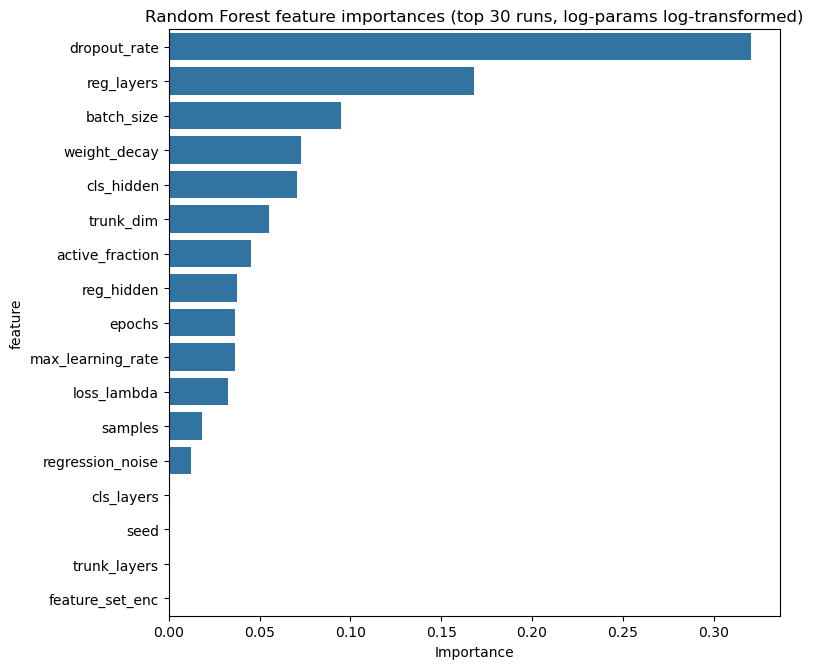

          feature  importance
     dropout_rate    0.320434
       reg_layers    0.167908
       batch_size    0.094954
     weight_decay    0.072608
       cls_hidden    0.070649
        trunk_dim    0.055143
  active_fraction    0.045010
       reg_hidden    0.037406
           epochs    0.036401
max_learning_rate    0.036375
      loss_lambda    0.032802
          samples    0.018053
 regression_noise    0.011961
       cls_layers    0.000295
             seed    0.000000
     trunk_layers    0.000000
  feature_set_enc    0.000000


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import math

hparam_cols = [c for c in df.columns if c not in ["run_id", "run_name", METRIC]]
numeric_cols = df[hparam_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df[hparam_cols].select_dtypes(exclude=[np.number]).columns.tolist()

le = LabelEncoder()
le.fit(df["feature_set"])

X_rf = df[numeric_cols].copy().astype(float)
for col in numeric_cols:
    if col in LOG_PARAMS:
        X_rf[col] = np.log(X_rf[col].clip(lower=1e-9))
X_rf["feature_set_enc"] = le.transform(df["feature_set"])
y_rf = df[METRIC].astype(float)

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_rf, y_rf)

importance_df = (
    pd.DataFrame({"feature": X_rf.columns, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, max(4, len(importance_df) * 0.4)))
sns.barplot(data=importance_df, x="importance", y="feature", ax=ax)
ax.set_title(f"Random Forest feature importances (top {TOP_N} runs, log-params log-transformed)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
print(importance_df.to_string(index=False))

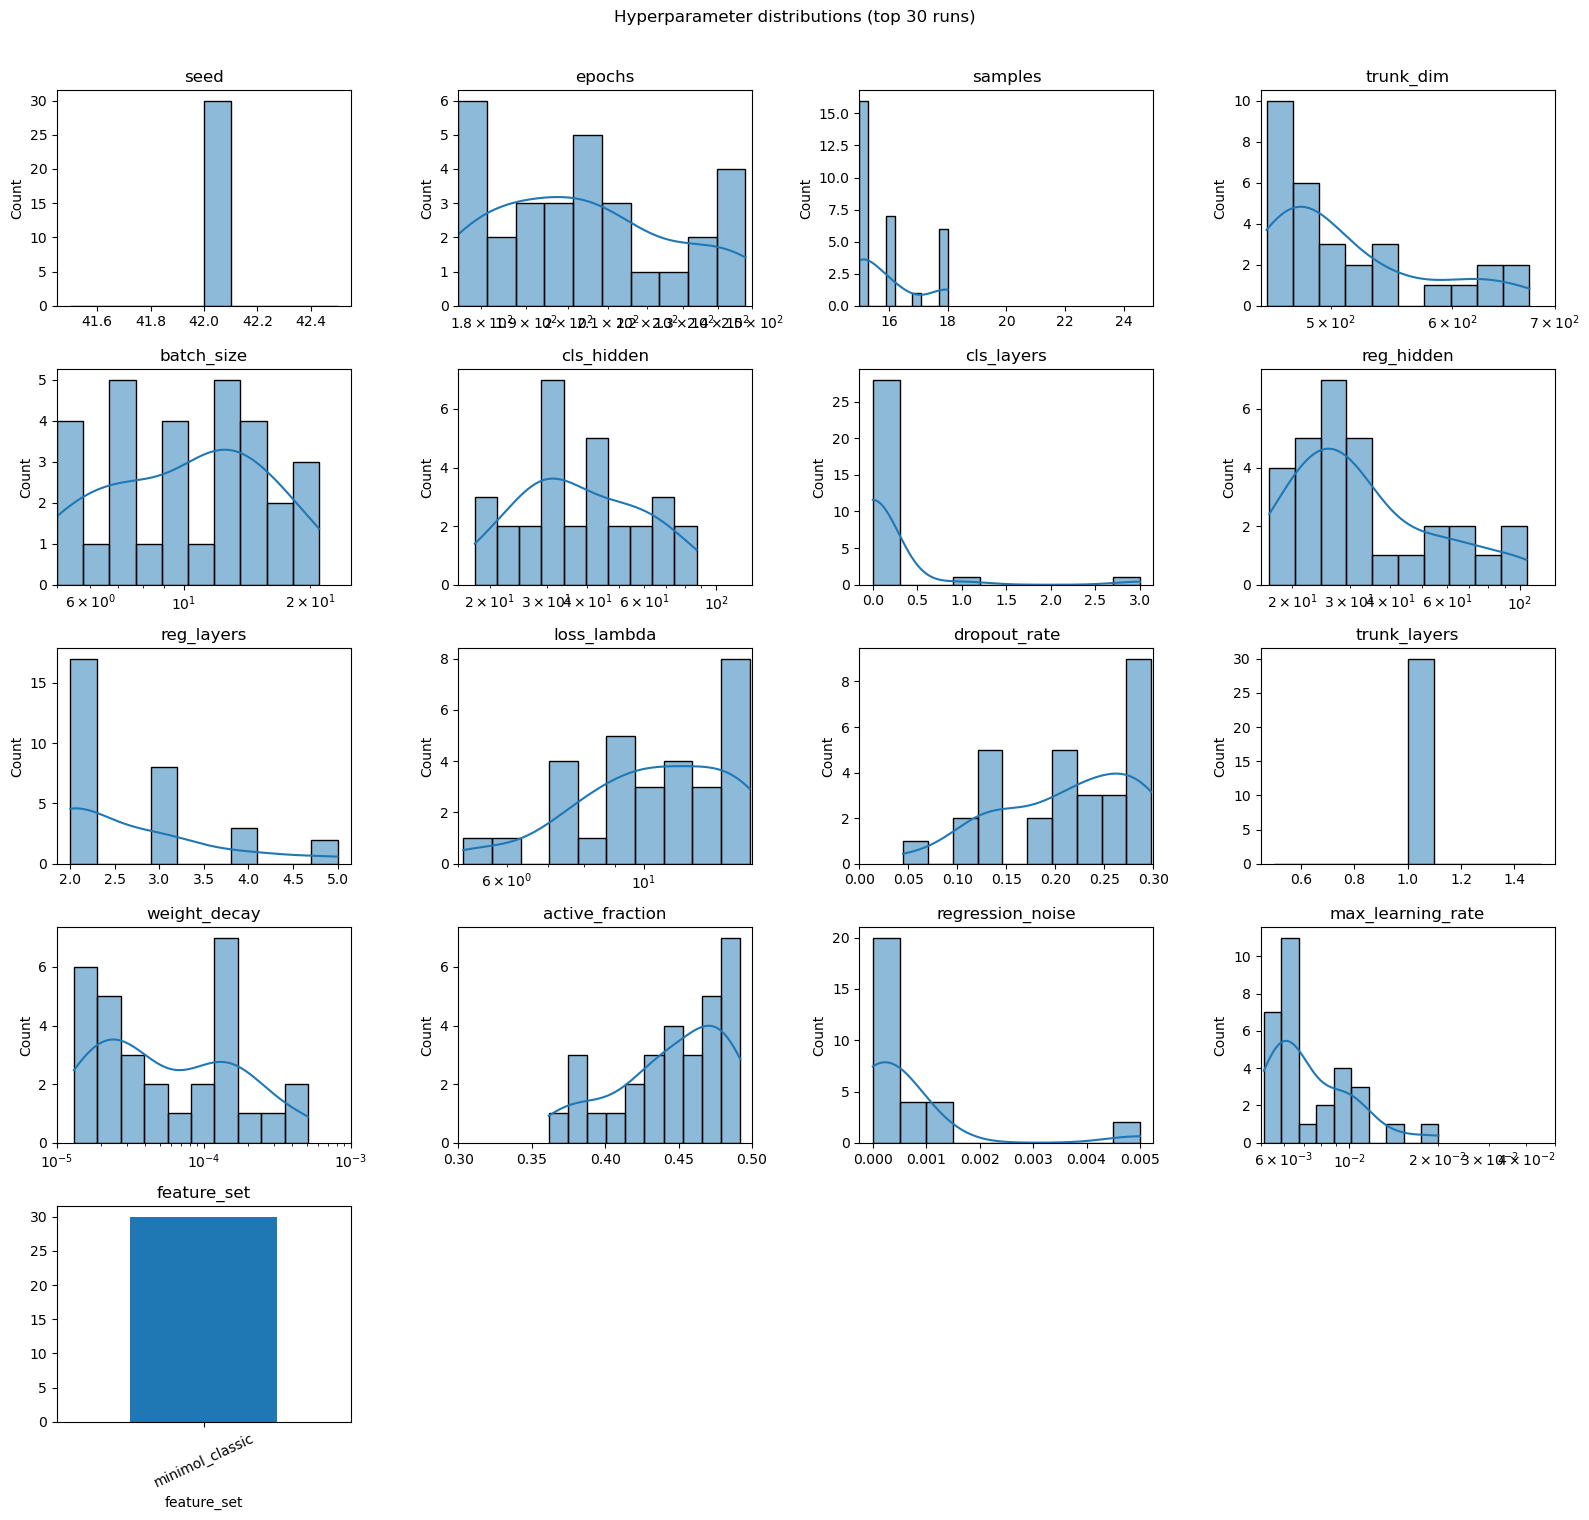

In [6]:
# --- Distribution plots: histogram+KDE for numeric, bar for categorical ---
all_cols = numeric_cols + cat_cols
n_cols = 4
n_rows = math.ceil(len(all_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    is_log = col in LOG_PARAMS
    if is_log:
        ax.set_xscale("log")
    sns.histplot(df[col], kde=True, ax=ax, bins=10)
    if col in PARAM_XLIM:
        ax.set_xlim(PARAM_XLIM[col])
    ax.set_title(col)
    ax.set_xlabel("")

for j, col in enumerate(cat_cols):
    idx = len(numeric_cols) + j
    df[col].value_counts().plot(kind="bar", ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].tick_params(axis="x", rotation=25)

for k in range(len(all_cols), len(axes)):
    axes[k].set_visible(False)

fig.suptitle(f"Hyperparameter distributions (top {TOP_N} runs)", y=1.01)
plt.tight_layout()
plt.show()

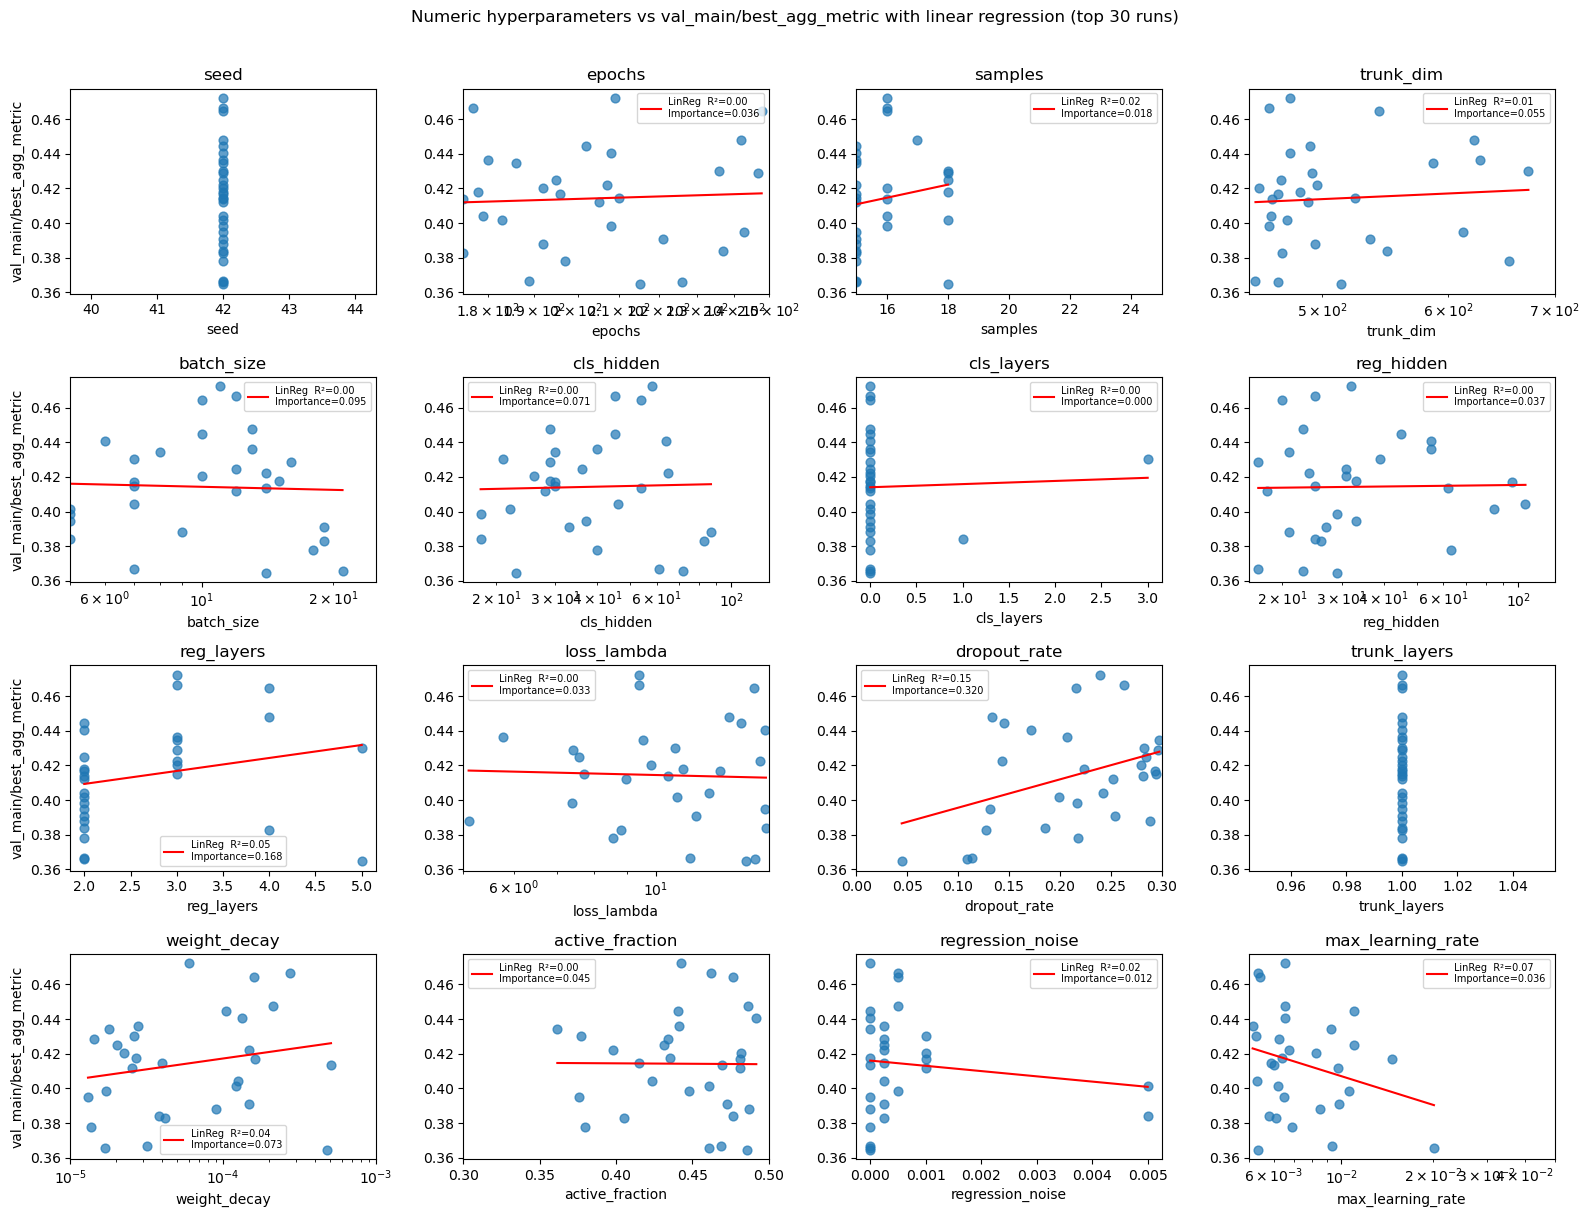

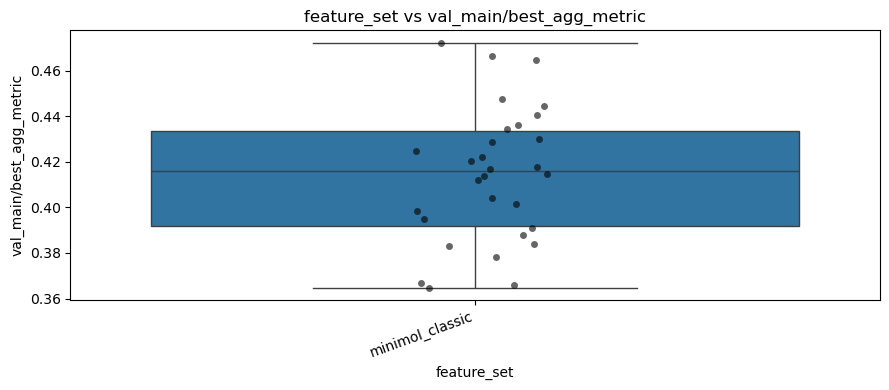

In [7]:
from scipy.stats import linregress

# --- Scatter plots: numeric hparams vs metric with linear regression ---
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

imp_lookup = dict(zip(importance_df["feature"], importance_df["importance"]))

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    x_raw = df[col].astype(float).values
    y = df[METRIC].astype(float).values
    is_log = col in LOG_PARAMS

    ax.scatter(x_raw, y, alpha=0.7, s=40)

    if is_log:
        ax.set_xscale("log")
        x_fit = np.log(np.clip(x_raw, 1e-9, None))
    else:
        x_fit = x_raw

    if col in PARAM_XLIM:
        ax.set_xlim(PARAM_XLIM[col])

    if len(np.unique(x_fit)) > 2:
        slope, intercept, r, p, _ = linregress(x_fit, y)
        x_sorted = np.sort(x_raw)
        x_fit_sorted = np.log(np.clip(x_sorted, 1e-9, None)) if is_log else x_sorted
        y_pred = slope * x_fit_sorted + intercept
        imp = imp_lookup.get(col, 0.0)
        ax.plot(x_sorted, y_pred, "r-", linewidth=1.5,
                label=f"LinReg  R²={r**2:.2f}\nImportance={imp:.3f}")
        ax.legend(fontsize=7)

    ax.set_xlabel(col)
    ax.set_ylabel(METRIC if i % n_cols == 0 else "")
    ax.set_title(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Numeric hyperparameters vs {METRIC} with linear regression (top {TOP_N} runs)", y=1.01)
plt.tight_layout()
plt.show()

# --- Categorical: feature_set vs metric ---
fig, ax = plt.subplots(figsize=(9, 4))
order = df.groupby("feature_set")[METRIC].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x="feature_set", y=METRIC, order=order, ax=ax)
sns.stripplot(data=df, x="feature_set", y=METRIC, order=order, ax=ax,
              color="black", size=5, alpha=0.6, jitter=True)
ax.set_title(f"feature_set vs {METRIC}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("top30_runs.csv", index=False)
print("Saved top30_runs.csv")